In [1]:
import os
# Force CPU backend on Apple Silicon to avoid Metal issues
os.environ['JAX_PLATFORMS'] = 'cpu'

# Disable LaTeX rendering in matplotlib
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.bottom': False,
    'axes.spines.left': False,
    'xtick.major.size': 0,
    'ytick.major.size': 0,
    'xtick.minor.size': 0,
    'ytick.minor.size': 0,
})

import jax.numpy as jnp
from jax import random
import numpy as np
from collections import defaultdict

from aind_behavior_vrforaging_analysis.sbi_ddm_analysis.simulator import PatchForagingDDM_JAX

In [ ]:
simulator = PatchForagingDDM_JAX()

#parameters grabbed from session 745305_20241212T105857_Methyl_butyrate model snle_2M_lr0.0005_ts2000_h128_l8_b128_37feat
drift_rate = -.15
reward_bump = -0.3
failure_bump = .6
noise_std = 0.1

theta = jnp.array([drift_rate, reward_bump, failure_bump, noise_std])
max_sites_per_window = 1000

In [3]:
def extract_state_transitions(window_data):
    """
    Extract (state, outcome) pairs from window_data.
    
    Returns list of tuples: [(n_rewards, n_failures, left_patch), ...]
    where left_patch is True if animal left, False if stayed
    """
    transitions = []
    
    total_rewards = 0
    total_failures = 0
    consecutive_failures = 0
    consecutive_rewards = 0
    prev_patch_time = 0
    
    for site_idx in range(len(window_data)):
        patch_time, reward, stopped = window_data[site_idx]
        
        # Skip padding (all zeros after simulation ends)
        if patch_time == 0 and site_idx > 0:
            break
        
        # Detect patch exit: patch_time reset (got smaller)
        left_patch = (patch_time < prev_patch_time) if site_idx > 0 else False
        
        if left_patch:
            # Record the state BEFORE leaving
            # (use previous site's state)
            transitions.append((total_rewards, total_failures, consecutive_failures, consecutive_rewards, True))
            
            # Reset state for new patch
            total_rewards = 0
            total_failures = 0
            consecutive_failures = 0
            consecutive_rewards = 0
        else:
            # Animal stayed, record this state
            if site_idx > 0:  # Don't record first site (entering patch)
                transitions.append((total_rewards, total_failures, consecutive_failures, consecutive_rewards, False))
            
            # Update state based on this site's outcome
            if reward > 0:
                total_rewards += 1
                consecutive_rewards += 1
                consecutive_failures = 0  # Reset failures after reward
            else:
                total_failures += 1
                consecutive_failures += 1
                consecutive_rewards = 0  # Reset rewards after failure
        
        prev_patch_time = patch_time
    
    return transitions

In [4]:
n_simulations = 1000
rng_key = random.PRNGKey(42)

# Store all raw transitions
all_transitions = []

for i in range(n_simulations):
    if i % (n_simulations // 10) == 0:
        print(f"Simulation {i}/{n_simulations}")
    
    rng_key, subkey = random.split(rng_key)
    window_data, _ = simulator.simulate_one_window(theta, subkey)
    
    transitions = extract_state_transitions(window_data)
    all_transitions.extend(transitions)

print(f"Collected {len(all_transitions)} total transitions")

Simulation 0/1000
Simulation 100/1000
Simulation 200/1000
Simulation 300/1000
Simulation 400/1000
Simulation 500/1000
Simulation 600/1000
Simulation 700/1000
Simulation 800/1000
Simulation 900/1000
Collected 499000 total transitions


In [5]:

# Flexible aggregation function
def aggregate_by_state(transitions, state_fn):
    """
    transitions: list of (n_rewards, n_failures, n_consecutive_failures, n_consecutive_rewards, left)
    state_fn: function that takes (n_rewards, n_failures, n_consecutive_failures, n_consecutive_rewards) 
              and returns a state key
    """
    state_counts = defaultdict(lambda: {'left': 0, 'stayed': 0})
    
    for n_rewards, n_failures, n_consecutive_failures, n_consecutive_rewards, left in transitions:
        state = state_fn(n_rewards, n_failures, n_consecutive_failures, n_consecutive_rewards)
        if left:
            state_counts[state]['left'] += 1
        else:
            state_counts[state]['stayed'] += 1
    
    return state_counts


# Create the specific aggregation you want: total rewards x consecutive failures
cross_counts = aggregate_by_state(
    all_transitions,
    lambda r, f, cf, cr: (r, cf)
)


Non-NaN cells: 136


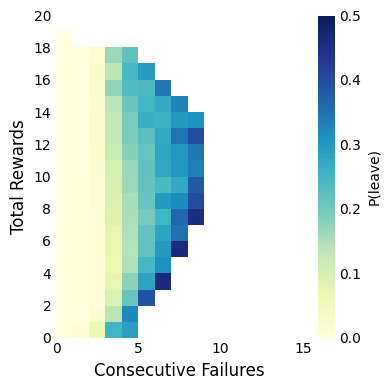

In [6]:
# Plotting
max_rewards = 20
max_consecutive_failures = 15
min_visits = 200

prob_leave = np.full((max_rewards, max_consecutive_failures), np.nan)

for rewards in range(max_rewards):
    for consecutive_failures in range(max_consecutive_failures):
        state = (rewards, consecutive_failures)
        if state in cross_counts:
            counts = cross_counts[state]
            total = counts['left'] + counts['stayed']
            if total > min_visits:
                prob_leave[rewards, consecutive_failures] = counts['left'] / total

print(f"Non-NaN cells: {np.sum(~np.isnan(prob_leave))}")

fig, ax = plt.subplots(figsize=(4, 4))

im = ax.imshow(prob_leave, origin='lower', aspect='auto', 
               cmap='YlGnBu', vmin=0, vmax=0.5,
               extent=[0, max_consecutive_failures, 0, max_rewards])

ax.set_xlabel('Consecutive Failures', fontsize=12)
ax.set_ylabel('Total Rewards', fontsize=12)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Minimal ticks
ax.tick_params(length=0)

# Integer ticks on y-axis
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

cbar = plt.colorbar(im, ax=ax, label='P(leave)')
cbar.outline.set_visible(False)
cbar.ax.tick_params(length=0)

plt.tight_layout()
plt.show()